<font size=6><b>Lec07.딥러닝 RNN - 시계열
* https://keras.io/api/datasets/mnist/
* https://otexts.com/fppkr/index.html - 교재

<b><big> 📊 Lec.07 딥러닝 RNN - 시계열 데이터셋 목록</b></big>

| 난이도 | Dataset | 설명 | 특징 | 데이터 크기 | Kaggle URL |
| :--- | :--- | :--- | :--- | :--- | :--- |
| ⭐ | **Shampoo Sales** | 월별 샴푸 판매량 | RNN 기초 학습 | 36 rows | [Link](https://www.kaggle.com/datasets/jbrownlee/shampoo-sales) |
| ⭐ | **Airline Passengers** | 월별 국제 항공 승객 수 | 주기, 계절성 학습 | 144 rows | [Link](https://www.kaggle.com/datasets/rakannimer/air-passengers) |
| ⭐⭐ | **Daily Min Temp** | 멜버른 일별 최소 기온 | 계절성 학습 | 3,650 rows | [Link](https://www.kaggle.com/datasets/jbrownlee/daily-minimum-temperatures-in-me) |
| ⭐⭐ | **Sunspots** | 태양 흑점 수 | 주기성 데이터 | ~2,820 rows | [Link](https://www.kaggle.com/datasets/rohanrao/sunspots) |
| ⭐⭐ | **Bitcoin Price** | 비트코인 가격 시계열 | 노이즈 금융 데이터 | ~5,000+ rows | [Link](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data) |
| ⭐⭐⭐ | **Electricity** | 전력 사용량 시계열 | 대규모 다변량 | 200,000+ rows | [Link](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption) |
| ⭐⭐⭐ | **Traffic Volume** | 교통량 데이터 | 다변량(날씨, 시간) | ~48,000 rows | [Link](https://www.kaggle.com/datasets/uciml/metro-interstate-traffic-volume) |
| ⭐⭐⭐⭐ | **Stock Market** | 주가 시계열 | 다종목 금융 데이터 | ~20,000+ rows | [Link](https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset) |
| ⭐⭐⭐⭐⭐ | **M5 Forecasting** | 대형 시계열 예측 | 세계 최대 리테일 대회 | 30M+ rows | [Link](https://www.kaggle.com/competitions/m5-forecasting-accuracy) |


# <font color=red><b>시계열 데이터
* https://otexts.com/fppkr/
* <font color=red><b>정상성 데이터(Stationary)</b></font>
    - 평균, 분산이 시간에 관계없이 일정한 데이터로 통계적으로 안정적
    - 예측이나 모델링이 용이(주식의 일별 수익률)
* <font color=red><b>비정상성 데이터(Non-Stationary)</b></font>
    - 시간에 따라 평균, 분산이 변화
    - 예측이 어렵고 통계 분석이 제한되므로 분석 전에 정상화 처리 필수
* <font color=red><b>비정상성 --> 정상성</b></font>
    - 평균 : 이동평균(MA:Moving Average), 차분(Difference)
    - 분산 : 스케일링(MinMax), 로그변환(값이양수인경우)

# <b> <font color = red>시계열 데이터 특징

* <font color=red><b>추세(trend)</b></font>
  - 증가 감소 패턴
  - 물가상승
* <font color=red><b>계절성(seasonality)</b></font>
  - 짧은(주, 요일, 월) 빈도로 보이는 패턴(대체로 일정)
  - 블랙프라이데이 매출, 여름철우산판매량
* <font color=red><b>주기성(cycle)</b></font>
  - 장기적(고정 빈도가 없다)으로 증가/감소 패턴
  - 경기 순환(business cycle)
* <font color=red><b>백색잡음(white noise == epsilon)</b></font>
  - 균일한 크기의 무작위적 잡음

<font size=6><b>Air Passengers
* https://www.kaggle.com/datasets/rakannimer/air-passengers

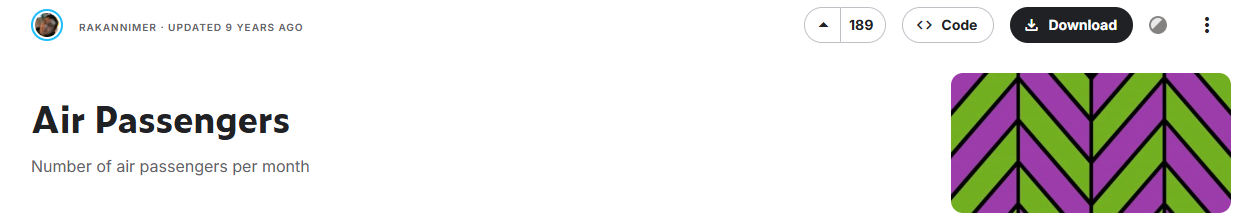

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------------- EDA image_load
import os
from PIL import Image
from tensorflow.keras.utils import load_img, image_dataset_from_directory, img_to_array

from sklearn.model_selection import train_test_split                   
#-----------------------------------------------------------------------------------  ML 모델
from sklearn.tree import DecisionTreeClassifier 
#----------------------------------------------------------------------------------   DL 모델
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D   # CNN관련
from tensorflow.keras.layers import Dense, Flatten, Rescaling                   # 일반 DL관련
from tensorflow.keras.initializers import GlorotNormal #Xavier
from tensorflow.keras.applications import MobileNetV2  #최소 이미지 크기 (32*32)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
#----------------------------------------------------------------------------------  평가
# from sklearn.metrics  import accuracy_score,      f1_score         -- 내부적으로 판단하므로 평가 (X)

import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)



# =========================================================================================

import warnings
warnings.filterwarnings('ignore')


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# <b> DATA load

In [2]:
df = pd.read_csv('./Airpassengers/AirPassengers.csv')
df.head(2)

,Month,#Passengers
0,1949-01,112
1,1949-02,118


In [3]:
df = pd.read_csv('./Airpassengers/AirPassengers.csv', parse_dates=["Month"])
df.columns = ["rdate","cnt"]
df["rdate"] = pd.to_datetime(df["rdate"]).dt.strftime("%Y-%m")
df.head(2)

#df["rdate"] = df["rdate"].dt.strftime("%Y-%m") #dt :데이터 형태가 date time이어야한다
#시계열 기본 패턴
#df = pd.read_csv(..., parse_dates=[날짜컬럼])
#df.set_index("날짜컬럼", inplace=True)
#plt.plot(df["값"])

,rdate,cnt
0,1949-01,112
1,1949-02,118


# EDA

In [4]:
df = df.set_index("rdate")
df.head(2)

,cnt
rdate,
1949-01,112
1949-02,118


In [5]:
df.index.min(),df.index.max()

('1949-01', '1960-12')

<Figure size 640x480 with 0 Axes>

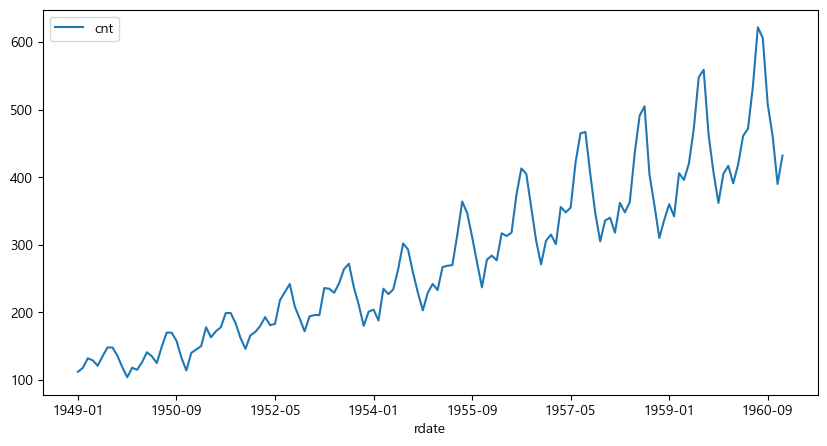

In [6]:
plt.figure()
df.plot(figsize=(10,5))  
plt.show();

# <b>전처리 & 가공

* <font color=red><b>정상성 데이터(Stationary)</b></font>
    - 평균, 분산이 시간에 관계없이 일정한 데이터로 통계적으로 안정적
    - 예측이나 모델링이 용이(주식의 일별 수익률)
* <font color=red><b>비정상성 --> 정상성
    - 평균 : 이동평균(MA:Moving Average), 차분(Difference)
    - 분산 : 스케일링(MinMax), 로그변환(값이양수인경우)

# 차분(Difference)

In [11]:
df['diff1'] = df['cnt'].diff(1) #1일전과의 비교
df['diff1'] = df['diff1'].bfill() #결측 채우기
df.head()

,cnt,ma5,ma20,diff1
rdate,,,,
1949-01,112,122.4,132.55,6.0
1949-02,118,122.4,132.55,6.0
1949-03,132,122.4,132.55,14.0
1949-04,129,122.4,132.55,-3.0
1949-05,121,122.4,132.55,-8.0


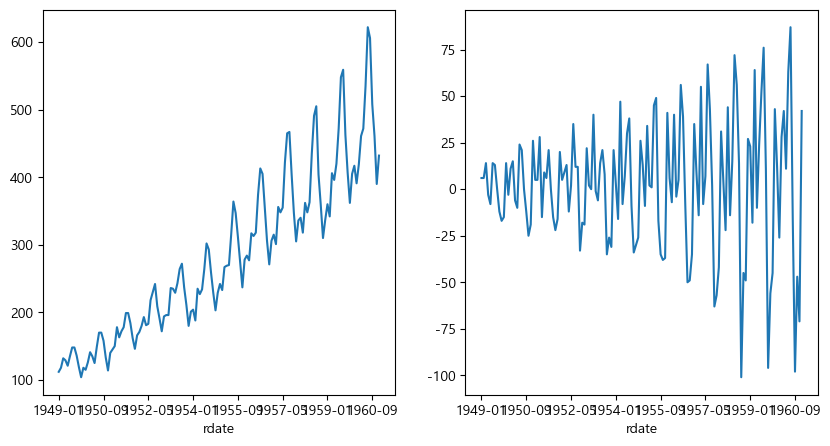

In [12]:
plt.figure()
plt.subplot(1,2,1)
df['cnt'].plot(figsize=(10,5))  

plt.subplot(1,2,2)
df['diff1'].plot(figsize=(10,5))  
  
plt.show();

# 이동평균(MA)
* 5일(w), 20일(m), 60일(q), 120(2q:상하반기), 200일(y)

분산 없애려고 이동평균구함

In [7]:
df['ma5'] = df['cnt'].rolling(5).mean()
df['ma20'] = df['cnt'].rolling(20).mean()
df.head()

,cnt,ma5,ma20
rdate,,,
1949-01,112,NaN,NaN
1949-02,118,NaN,NaN
1949-03,132,NaN,NaN
1949-04,129,NaN,NaN
1949-05,121,122.4,NaN


## 결측 채우기 :앞/뒤 값으로 채우기
<pre><font color=red><b>df['컬럼'] = df['컬럼'].ffill() : 앞값으로 채우기
df['컬럼'] = df['컬럼'].bfill() : 뒤값으로 채우기</font color=red></b>

inplace=True XXXXXXXXXXXXXXXXXXXXXXXXXX
시계열 데이터는 보통 앞뒤값의 평균으로 채움

In [8]:
df['ma5'] = df['ma5'].bfill()
df['ma20'] = df['ma20'].bfill()
df.head(6)

,cnt,ma5,ma20
rdate,,,
1949-01,112,122.4,132.55
1949-02,118,122.4,132.55
1949-03,132,122.4,132.55
1949-04,129,122.4,132.55
1949-05,121,122.4,132.55
1949-06,135,127.0,132.55


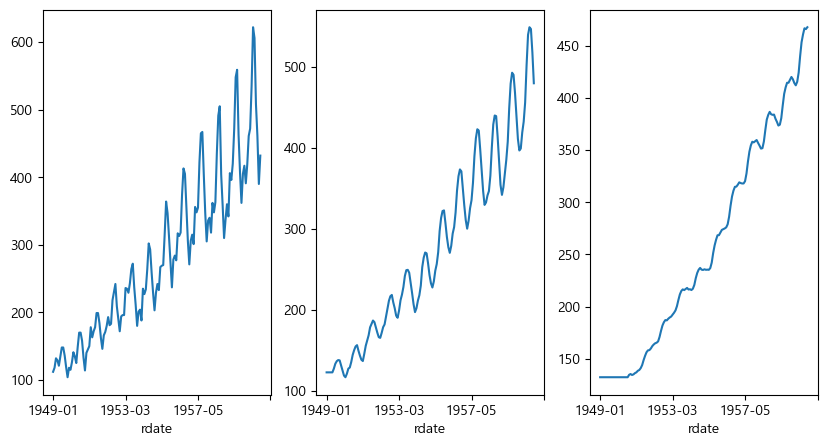

In [9]:
plt.figure()
plt.subplot(1,3,1)
df['cnt'].plot(figsize=(10,5))  

plt.subplot(1,3,2)
df['ma5'].plot(figsize=(10,5))  

plt.subplot(1,3,3)
df['ma20'].plot(figsize=(10,5))  
plt.show();

# 로그변환(값이양수인경우)

In [13]:
df['log'] = np.log1p(df['cnt'])
df.head()

,cnt,ma5,ma20,diff1,log
rdate,,,,,
1949-01,112,122.4,132.55,6.0,4.727388
1949-02,118,122.4,132.55,6.0,4.779123
1949-03,132,122.4,132.55,14.0,4.890349
1949-04,129,122.4,132.55,-3.0,4.867534
1949-05,121,122.4,132.55,-8.0,4.804021


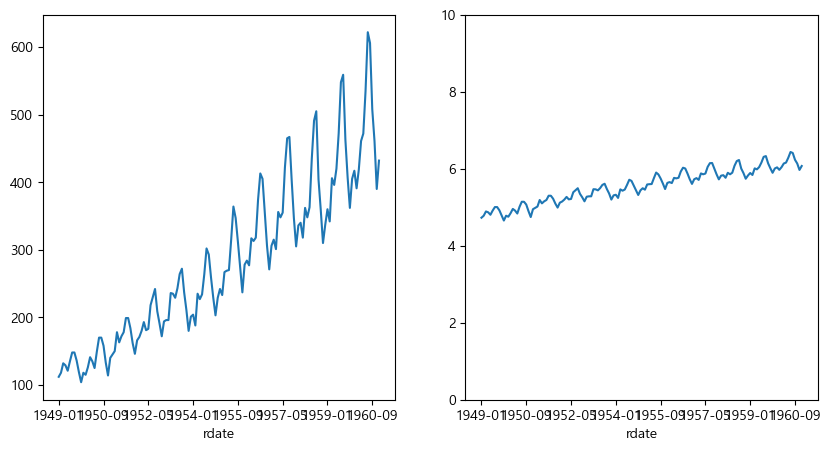

In [16]:
plt.figure()
plt.subplot(1,2,1)
df['cnt'].plot(figsize=(10,5))  

plt.subplot(1,2,2)
df['log'].plot(figsize=(10,5))  

plt.ylim(0,10) # y축고정 : 변동폭 사라짐
plt.show();

# 스케일링(MinMax)

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
res = scaler.fit_transform(df['cnt'].values.reshape(-1,1)) #스케일링할때 2차부터 가능
res [:5]

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853]])

In [19]:
df['scale'] = res.reshape(-1)
df.head(5)

,cnt,ma5,ma20,diff1,log,scale
rdate,,,,,,
1949-01,112,122.4,132.55,6.0,4.727388,0.015444
1949-02,118,122.4,132.55,6.0,4.779123,0.027027
1949-03,132,122.4,132.55,14.0,4.890349,0.054054
1949-04,129,122.4,132.55,-3.0,4.867534,0.048263
1949-05,121,122.4,132.55,-8.0,4.804021,0.032819


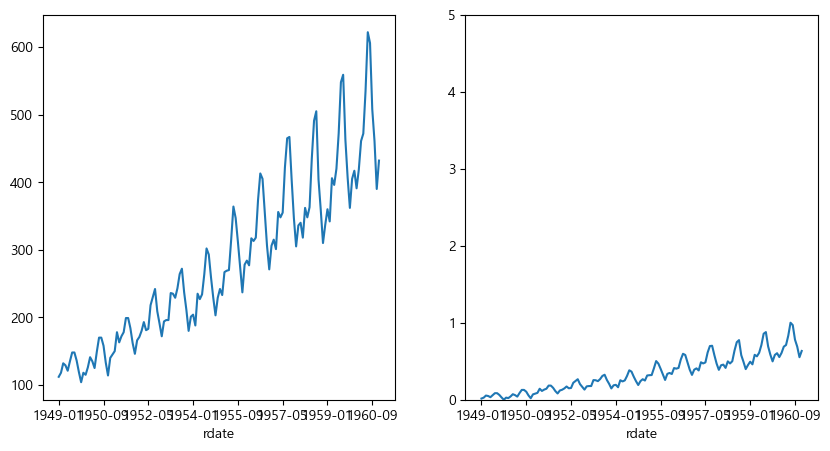

In [22]:
plt.figure()
plt.subplot(1,2,1)
df['cnt'].plot(figsize=(10,5))  

plt.subplot(1,2,2)
df['scale'].plot(figsize=(10,5))  

plt.ylim(0,5) # minmax는 값 범위 제한해서 0~1사이의 값으로 나와야함
plt.show();

## 정상성 데이터
* 평균(차분), 분산(log)

In [23]:
df['stat'] = np.log1p(df['cnt'])
df['stat'] = df['stat'].diff(1)
df['stat'] = df['stat'].bfill()
df.head(2)

,cnt,ma5,ma20,diff1,log,scale,stat
rdate,,,,,,,
1949-01,112,122.4,132.55,6.0,4.727388,0.015444,0.051736
1949-02,118,122.4,132.55,6.0,4.779123,0.027027,0.051736


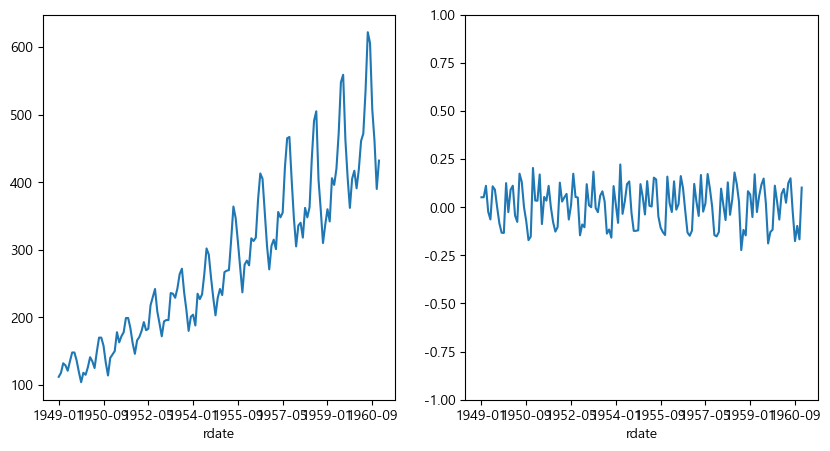

In [24]:
plt.figure()
plt.subplot(1,2,1)
df['cnt'].plot(figsize=(10,5))  

plt.subplot(1,2,2)
df['stat'].plot(figsize=(10,5))  
plt.ylim(-1,1)
plt.show();